# Inspect and select pseudo-bulk combinations

Interactive counterpart to `scBAMpler select-populations`. Use this when you want to see the
parameter space before committing to a set of populations; use the CLI when you want the same
selection applied automatically.

Inputs are the outputs of the two previous steps:

* the pickle from `scBAMpler make-pseudobulks` (`embedding_df`, `medoid_df`, `medoid_stats`, `cor_df`)
* the CSV from `scBAMpler mix-pseudobulks` (one row per candidate population)

## Contents
1. [Initial data visualization](#one)
2. [Combination generation](#two)
3. [Visualize the combination parameter space](#three)
4. [Select populations](#four)
5. [Write barcode files](#five)

### Extra dependencies
The pipeline itself does not need plotting libraries, so install them before running this notebook:

```
conda activate scBAMpler_env
pip install seaborn matplotlib jupyter
```

In [61]:
import ast
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist

sns.set(style='white', rc={"figure.dpi": 100, 'savefig.dpi': 300})
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

### Parameters
Everything below reads from these. 
`CLUSTER_SIZE` must match what was passed to `make-pseudobulks`.

In [62]:
# locate the repository root by walking up from wherever this kernel started
ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print(f"repository root: {ROOT}")

PICKLE      = ROOT / "example_output/medoids_s50.pickle"   # from make-pseudobulks
COMBOS_CSV  = ROOT / "example_output/combos_all.csv"       # from mix-pseudobulks
OUTDIR      = ROOT / "example_output/selected"             # where selections are written

LABEL_COL   = "CellLine"   # grouping column, --label-col in the CLI
CLUSTER_SIZE = 50          # --cluster-size used in make-pseudobulks

OUTDIR.mkdir(parents=True, exist_ok=True)

repository root: /Users/amandaeveritt/projects/scBAMpler


In [63]:
def build_palette(labels):
    labels = list(labels)
    colors = sns.color_palette("colorblind", n_colors=max(len(labels), 3)).as_hex()
    return dict(zip(labels, colors))

# 1. Initial data visualization <a class="anchor" id="one"></a>

In [64]:
with open(PICKLE, "rb") as f:
    embedding_df, medoid_df, medoid_stats, cor_df = pickle.load(f)

all_labels = np.unique(embedding_df[LABEL_COL])
custom_palette = build_palette(all_labels)

print(f"{len(embedding_df)} cells, {len(all_labels)} labels: {list(all_labels)}")
print(f"{medoid_df.shape[1]} pseudo-bulk profiles x {medoid_df.shape[0]} peaks")

print(f"\nThis is the cell-level information dataframe:")
display(embedding_df.head())
print(f"\nThis is the cluster and hypothetical population information dataframe:")
display(medoid_stats.head())

print(f"\nThis is the population correlation dataframe: ")
display(cor_df.iloc[:5, :5])

1111 cells, 3 labels: ['HEPG2', 'K562', 'MCF7']
24 pseudo-bulk profiles x 555362 peaks

This is the cell-level information dataframe:


,embedding1,embedding2,CB,CellLine,Cluster
0,2.107585,1.313425,HEPG2#ATGATAGGACCTAGGC,HEPG2,m2
1,2.914891,5.203110,HEPG2#AACTAGCACCGATCGC,HEPG2,m8
2,3.618047,3.500236,HEPG2#CTGCACGGAGATTAAG,HEPG2,m8
3,4.147140,6.059829,HEPG2#TAGTGCATGGCGCAAA,HEPG2,m5
4,2.007383,2.270513,HEPG2#TTGGTCCACGTCCCGA,HEPG2,m2



This is the cluster and hypothetical population information dataframe:


,Cluster,Kcenter_x,Kcenter_y,PeakReads
HEPG2,HEPG2,4.873397,2.951729,7533384
K562,K562,5.022666,3.024630,7808097
MCF7,MCF7,-16.038730,-9.685435,7439052
m1,m1,6.647037,3.330993,617684
m10,m10,5.552225,0.614130,465780



This is the population correlation dataframe: 


,HEPG2,K562,MCF7,m1,m10
HEPG2,1.000000,0.939087,0.565833,0.784595,0.702747
K562,0.939087,1.000000,0.572644,0.734085,0.752386
MCF7,0.565833,0.572644,1.000000,0.432343,0.438015
m1,0.784595,0.734085,0.432343,1.000000,0.544891
m10,0.702747,0.752386,0.438015,0.544891,1.000000


In [65]:
#Each cluster gets the label that most of its cells carry. `mix-pseudobulks` computes the same
#column internally, but it is not saved back into the pickle, so recompute it here.
    
cols = []
for i in np.unique(medoid_stats.Cluster):
    if i in set(all_labels):
        cols.append(i)                      # label centroids are their own dominant label
    else:
        df_sub = embedding_df.loc[embedding_df.Cluster == i]
        cols.append(df_sub[LABEL_COL].value_counts(normalize=True).idxmax())

medoid_stats["DominantLabel"] = cols
#medoid_stats["DominantLabel"].value_counts()

### 1.1 Dimensionality Embedding, by cell and by cluster centroid. 
Left: every cell, coloured by label, with the label centroids marked. 

Right: one point per pseudo-bulk cluster. The right panel is the pool that combinations are drawn from — if clusters
do not tile the embedding the way you expect, revisit `--cluster-size`.

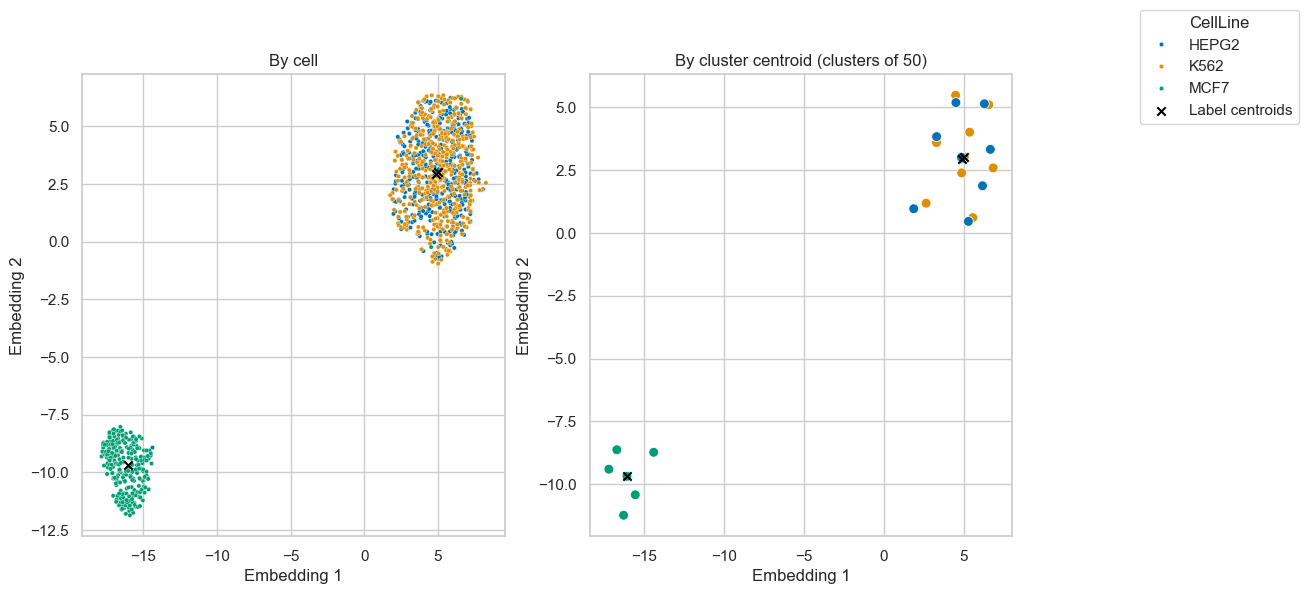

In [66]:
sns.set(style='whitegrid')
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(1, 2, figure=fig, wspace=0.2, hspace=0.05)

ax = fig.add_subplot(gs[0])
sns.scatterplot(x="embedding1", y="embedding2", hue=LABEL_COL,
                data=embedding_df, legend=True, s=10, palette=custom_palette, ax=ax)
ax.scatter(x="Kcenter_x", y="Kcenter_y",
           data=medoid_stats[medoid_stats.Cluster.isin(all_labels)],
           marker='x', color='black', label='Label centroids')
ax.set_xlabel("Embedding 1"); ax.set_ylabel("Embedding 2")
ax.set_title("By cell")
ax.get_legend().remove()

ax1 = fig.add_subplot(gs[1])
sns.scatterplot(x="Kcenter_x", y="Kcenter_y", hue='DominantLabel',
                data=medoid_stats, legend=True, s=50, palette=custom_palette, ax=ax1)
ax1.scatter(x="Kcenter_x", y="Kcenter_y",
            data=medoid_stats[medoid_stats.Cluster.isin(all_labels)],
            marker='x', color='black', label='Label centroids')
ax1.set_xlabel("Embedding 1"); ax1.set_ylabel("Embedding 2")
ax1.set_title(f"By cluster centroid (clusters of {CLUSTER_SIZE})")
ax1.get_legend().remove()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title=LABEL_COL, bbox_to_anchor=(1, 1), loc='upper left', ncol=1)
plt.show()

### 1.2 Similarity Dendrograms, by cell and by cluster.  

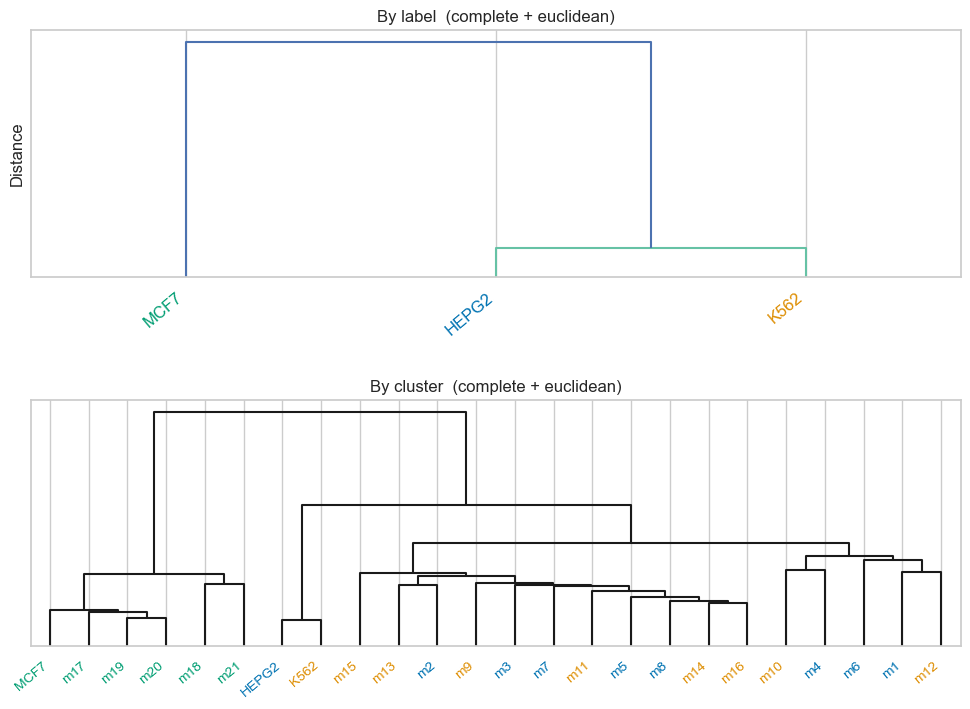

In [73]:
linkage_method = "complete"    # or: average, single, ward
distance_metric = "euclidean"  # or: correlation, cityblock, cosine

sns.set(style='whitegrid')
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 1, figure=fig, hspace=0.5)

# ── by label ──
ax = fig.add_subplot(gs[0])
corr_matrix = cor_df.loc[all_labels, all_labels]
link_mat = sch.linkage(pdist(corr_matrix, metric=distance_metric), method=linkage_method)
sch.dendrogram(link_mat, ax=ax, labels=corr_matrix.columns.to_list())
ax.set_title(f"By label  ({linkage_method} + {distance_metric})")
ax.set_ylabel("Distance")
ax.set_yticks([])
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
for label in ax.get_xticklabels():
    label.set_color(custom_palette.get(label.get_text(), "black"))

# ── by cluster ──
ax1 = fig.add_subplot(gs[1])
link_mat = sch.linkage(pdist(cor_df, metric=distance_metric), method=linkage_method)
sch.set_link_color_palette(list(sns.color_palette("Set2").as_hex()))
sch.dendrogram(link_mat, above_threshold_color='k', color_threshold=0,
               labels=cor_df.columns.to_list(), ax=ax1)
ax1.set_title(f"By cluster  ({linkage_method} + {distance_metric})")
ax1.set_yticks([])
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=40, ha="right")
for label in ax1.get_xticklabels():
    label.set_color(custom_palette[medoid_stats.loc[label.get_text()]["DominantLabel"]])

plt.show()

### 1.3 Correlation matrix
The matrix `mix-pseudobulks` scores against. Block structure along the diagonal corresponds to
labels.

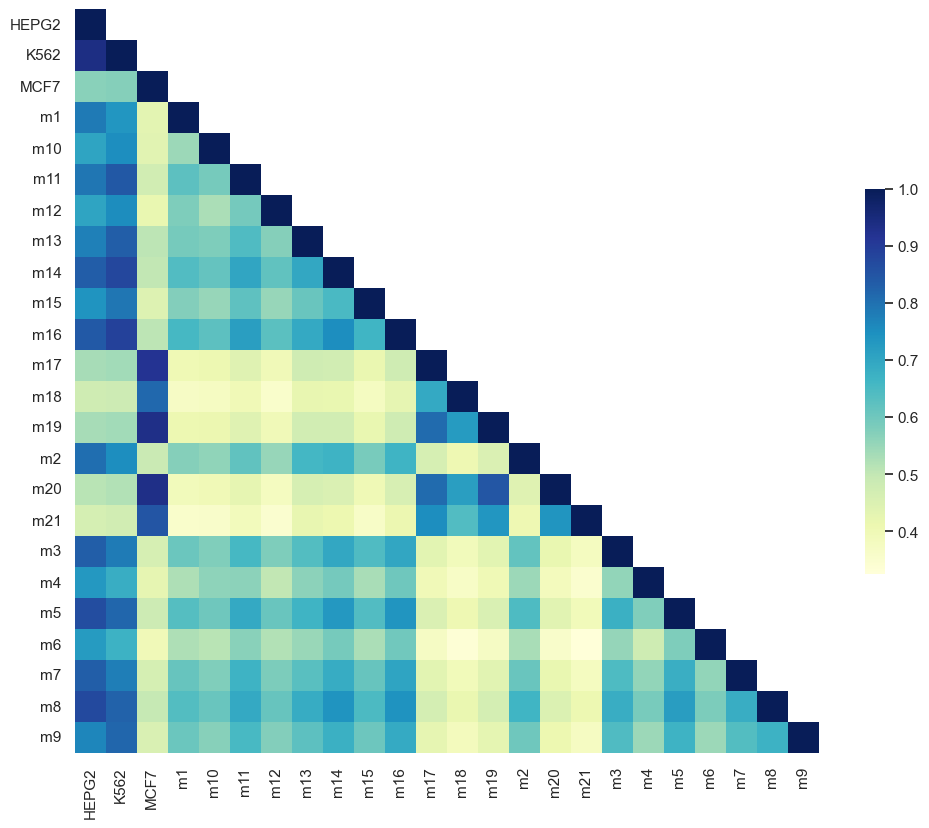

In [74]:
sns.set(style='white')
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(cor_df, dtype=bool), k=1)
sns.heatmap(cor_df, mask=mask, cmap='YlGnBu', square=True,
            cbar_kws={"shrink": .5}, rasterized=True, ax=ax)
#ax.set_yticklabels([]); ax.set_xticklabels([])
plt.show()

### 1.4 Similarity to each label, drawn on the embedding
Simple gut check that the per-cell correlations to the centroids are accurate. 

In [ ]:
#CLAUDE YOUR FORGOT TO 

In [76]:
display(embedding_df)

,embedding1,embedding2,CB,CellLine,Cluster
0,2.107585,1.313425,HEPG2#ATGATAGGACCTAGGC,HEPG2,m2
1,2.914891,5.203110,HEPG2#AACTAGCACCGATCGC,HEPG2,m8
2,3.618047,3.500236,HEPG2#CTGCACGGAGATTAAG,HEPG2,m8
3,4.147140,6.059829,HEPG2#TAGTGCATGGCGCAAA,HEPG2,m5
4,2.007383,2.270513,HEPG2#TTGGTCCACGTCCCGA,HEPG2,m2
...,...,...,...,...,...
1106,-16.383575,-11.286082,MCF7#GGGATTGGACCTTTGC,MCF7,m17
1107,-15.152580,-9.320551,MCF7#TGATAGAGAATGTGGG,MCF7,m18
1108,-15.731489,-10.324819,MCF7#TGGGCCATGATCAGCT,MCF7,m21
1109,-14.889768,-10.191013,MCF7#TCCGAGTCTGTGAGCA,MCF7,m21


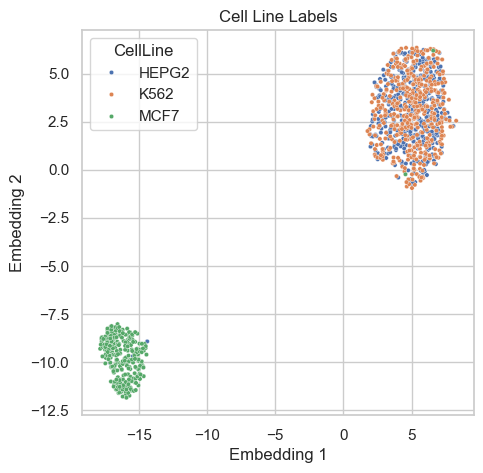

In [78]:
n = len(all_labels) + 1

fig = plt.figure(figsize=(6 * n, 5))
gs = GridSpec(1, n, figure=fig, wspace=0.25)

k=0
ax = fig.add_subplot(gs[k])
sns.scatterplot(x="embedding1", y="embedding2", hue="CellLine",
                data=embedding_df, legend=True, s=10, ax=ax)
ax.set_title("Cell Line Labels")
ax.set_xlabel("Embedding 1"); ax.set_ylabel("Embedding 2")

plt.show()

In [91]:
int(np.ceil((len(all_labels)+1)/2))

2

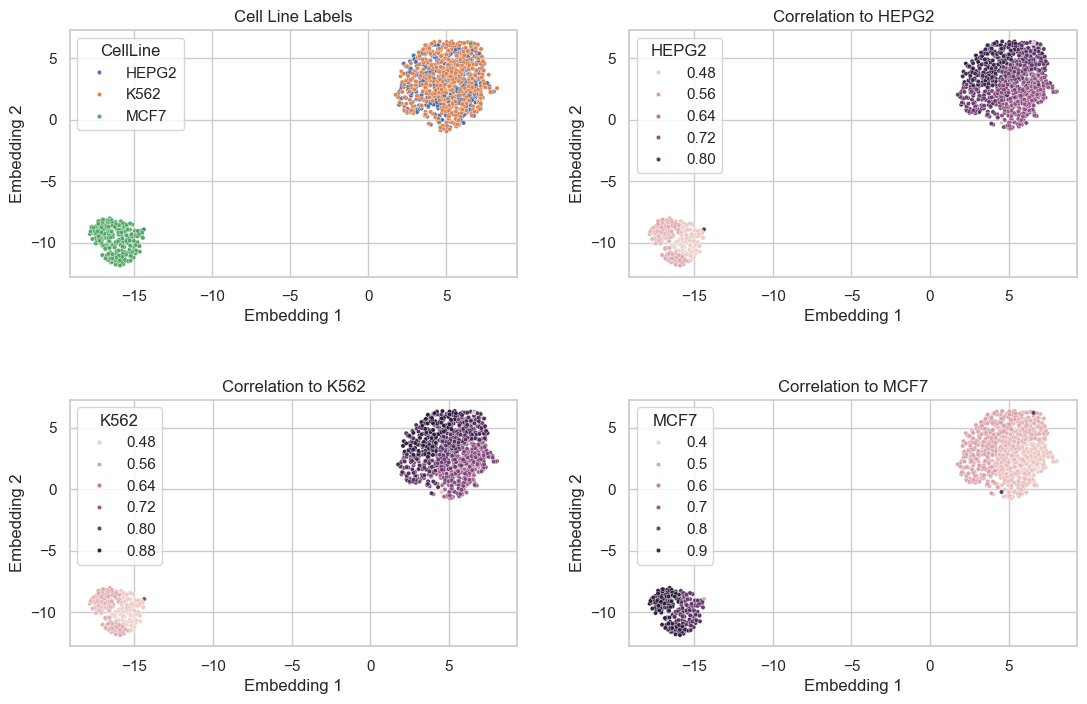

In [98]:
sns.set(style='whitegrid')
n = len(all_labels) + 1
fig = plt.figure(figsize=(3 * n+1, 8))
gs = GridSpec(2, int(np.ceil(n/2)), figure=fig, wspace=0.25, hspace=0.5)

ax = fig.add_subplot(gs[0])
sns.scatterplot(x="embedding1", y="embedding2", hue="CellLine",
                data=embedding_df, legend=True, s=10, ax=ax)
ax.set_title("Cell Line Labels")
ax.set_xlabel("Embedding 1"); ax.set_ylabel("Embedding 2")

for k, lab in enumerate(all_labels):
    ax = fig.add_subplot(gs[k+1])
    merged_df = pd.merge(embedding_df, cor_df[lab], left_on="Cluster",
                         right_index=True, how='inner')
    sns.scatterplot(x="embedding1", y="embedding2", hue=lab,
                    data=merged_df, legend=True, s=10, ax=ax)
    ax.set_title(f"Correlation to {lab}")
    ax.set_xlabel("Embedding 1"); ax.set_ylabel("Embedding 2")

plt.show()

# 2. Combination generation <a class="anchor" id="two"></a>

Generating and scoring candidate combinations is `scBAMpler mix-pseudobulks`, run before this
notebook. To build a mixed strategy, run it several times with different `--groups` and
concatenate the CSVs:

```
scBAMpler mix-pseudobulks --input example_output/medoids_s50.pickle \
    --output example_output/combos_all.csv --groups all \
    --n-combos 2000 --cluster-size 50 \
    --ft-sizes 200 300 400 500 600 700 800 900 1000

scBAMpler mix-pseudobulks --input example_output/medoids_s50.pickle \
    --output example_output/combos_k562_hepg2.csv --groups K562 HEPG2 \
    --n-combos 1000 --cluster-size 50 \
    --ft-sizes 200 300 400 500 600 700 800 900 1000

cat example_output/combos_all.csv example_output/combos_k562_hepg2.csv \
    > example_output/combos_combined.csv
```

# 3. Visualize the combination parameter space <a class="anchor" id="three"></a>

In [99]:
combo_df = pd.read_csv(COMBOS_CSV)

# group_medoids is written as a list literal; recover it as an actual list
combo_df["group_medoids"] = combo_df["group_medoids"].apply(ast.literal_eval)

print(f"{len(combo_df)} candidate combinations")
display(combo_df.head())

15351 candidate combinations


,group_medoids,total_peakreads,mean_pearson_corr,sse_pearson_corr,dominant_label,dominant_label_perc,closest_label,dist_to_HEPG2,dist_to_K562,dist_to_MCF7,groups_sampled
0,"[m12, m19, m4, m7]",3684269,0.479297,0.005294,HEPG2,50.0,HEPG2,0.300966,0.311801,0.438997,all
1,"[m11, m2, m6, m9]",3250135,0.586112,0.001826,HEPG2,50.0,HEPG2,0.228802,0.229333,0.547494,all
2,"[m17, m19, m21, m3]",5347340,0.590865,0.031242,MCF7,75.0,MCF7,0.410395,0.417159,0.209542,all
3,"[m12, m19, m2, m21]",4145964,0.481302,0.016893,MCF7,50.0,MCF7,0.373577,0.371333,0.327885,all
4,"[m12, m16, m18, m19]",4304755,0.501769,0.017474,K562,50.0,MCF7,0.360853,0.333737,0.331103,all


### 3.1 Distribution of each score
Sorted values for the three metrics. What matters is the *range*: a flat curve means every
candidate looks alike and there is no gradient to select along.

Pay attention if you seem to have outliers here. 

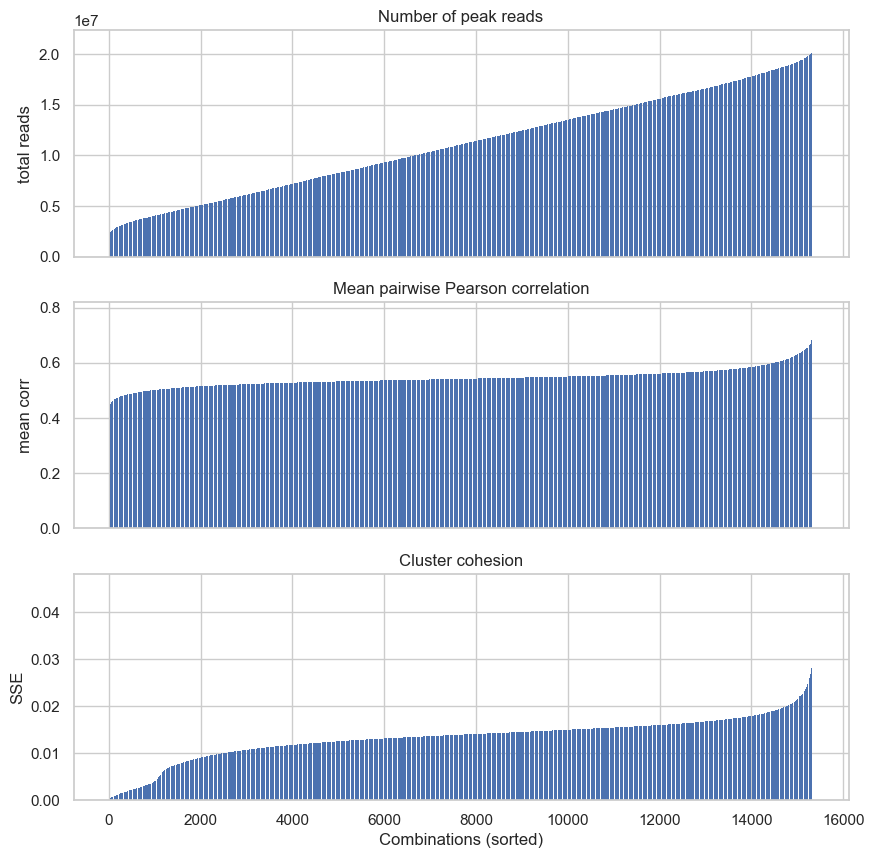

In [100]:
sorted_peakreads = np.sort(combo_df["total_peakreads"].values)
sorted_pearson_corr = np.sort(combo_df["mean_pearson_corr"].values)
sorted_sse = np.sort(combo_df["sse_pearson_corr"].values)
x_vals = np.arange(combo_df.shape[0])

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].bar(x_vals, sorted_peakreads, lw=0.)
axes[0].set_title('Number of peak reads'); axes[0].set_ylabel('total reads')

axes[1].bar(x_vals, sorted_pearson_corr, lw=0.)
axes[1].set_title('Mean pairwise Pearson correlation'); axes[1].set_ylabel('mean corr')

axes[2].bar(x_vals, sorted_sse, lw=0.)
axes[2].set_title('Cluster cohesion'); axes[2].set_ylabel('SSE')
axes[2].set_xlabel('Combinations (sorted)')

plt.show()

### 3.2 Annotate each combination

In [101]:
#Add a label so you can tell if the combination only comes from the same cell label. 
combo_df["sampling_type"] = "inter_label"
combo_df.loc[combo_df["dominant_label_perc"] == 100.0, "sampling_type"] = "intra_label"

# which --groups invocation produced the row, if the CSV is a concatenation of several runs
if combo_df["groups_sampled"].nunique() > 1:
    combo_df["sampling_type"] = (combo_df["sampling_type"] + " (" +
                                 combo_df["groups_sampled"].astype(str) + ")")
    
#Add number of cells per combination. 
combo_df["Number_of_Cells"] = combo_df["group_medoids"].apply(lambda x: len(set(x))) * CLUSTER_SIZE

print(combo_df.sampling_type.value_counts())
print()
print(combo_df.Number_of_Cells.value_counts().sort_index())

sampling_type
inter_label    15304
intra_label       47
Name: count, dtype: int64

Number_of_Cells
200     2000
300     2000
400     2000
500     2000
600     2000
700     2000
800     2000
900     1330
1000      21
Name: count, dtype: int64


### 3.3 One row per (combination, reference label)
`mix-pseudobulks` writes one `dist_to_<label>` column per label. Melting them into a single
`label_dist` column with a `dist_to_*` key makes it possible to facet by reference label, which
is how the rest of this notebook reads the space.

In [102]:
dist_cols = [c for c in combo_df.columns if c.startswith("dist_to_")]
id_cols = [c for c in combo_df.columns if c not in dist_cols]

combo_df_long = combo_df.melt(id_vars=id_cols, value_vars=dist_cols,
                              var_name="dist_to_*", value_name="label_dist")
combo_df_long["dist_to_*"] = combo_df_long["dist_to_*"].str.replace("dist_to_", "", regex=False)

print(f"{len(combo_df)} combinations x {len(dist_cols)} labels = {len(combo_df_long)} rows")
display(combo_df_long.head())

15351 combinations x 3 labels = 46053 rows


,group_medoids,total_peakreads,mean_pearson_corr,sse_pearson_corr,dominant_label,dominant_label_perc,closest_label,groups_sampled,sampling_type,Number_of_Cells,dist_to_*,label_dist
0,"[m12, m19, m4, m7]",3684269,0.479297,0.005294,HEPG2,50.0,HEPG2,all,inter_label,200,HEPG2,0.300966
1,"[m11, m2, m6, m9]",3250135,0.586112,0.001826,HEPG2,50.0,HEPG2,all,inter_label,200,HEPG2,0.228802
2,"[m17, m19, m21, m3]",5347340,0.590865,0.031242,MCF7,75.0,MCF7,all,inter_label,200,HEPG2,0.410395
3,"[m12, m19, m2, m21]",4145964,0.481302,0.016893,MCF7,50.0,MCF7,all,inter_label,200,HEPG2,0.373577
4,"[m12, m16, m18, m19]",4304755,0.501769,0.017474,K562,50.0,MCF7,all,inter_label,200,HEPG2,0.360853


### 3.4 Visualize how metrics relate to one another. 


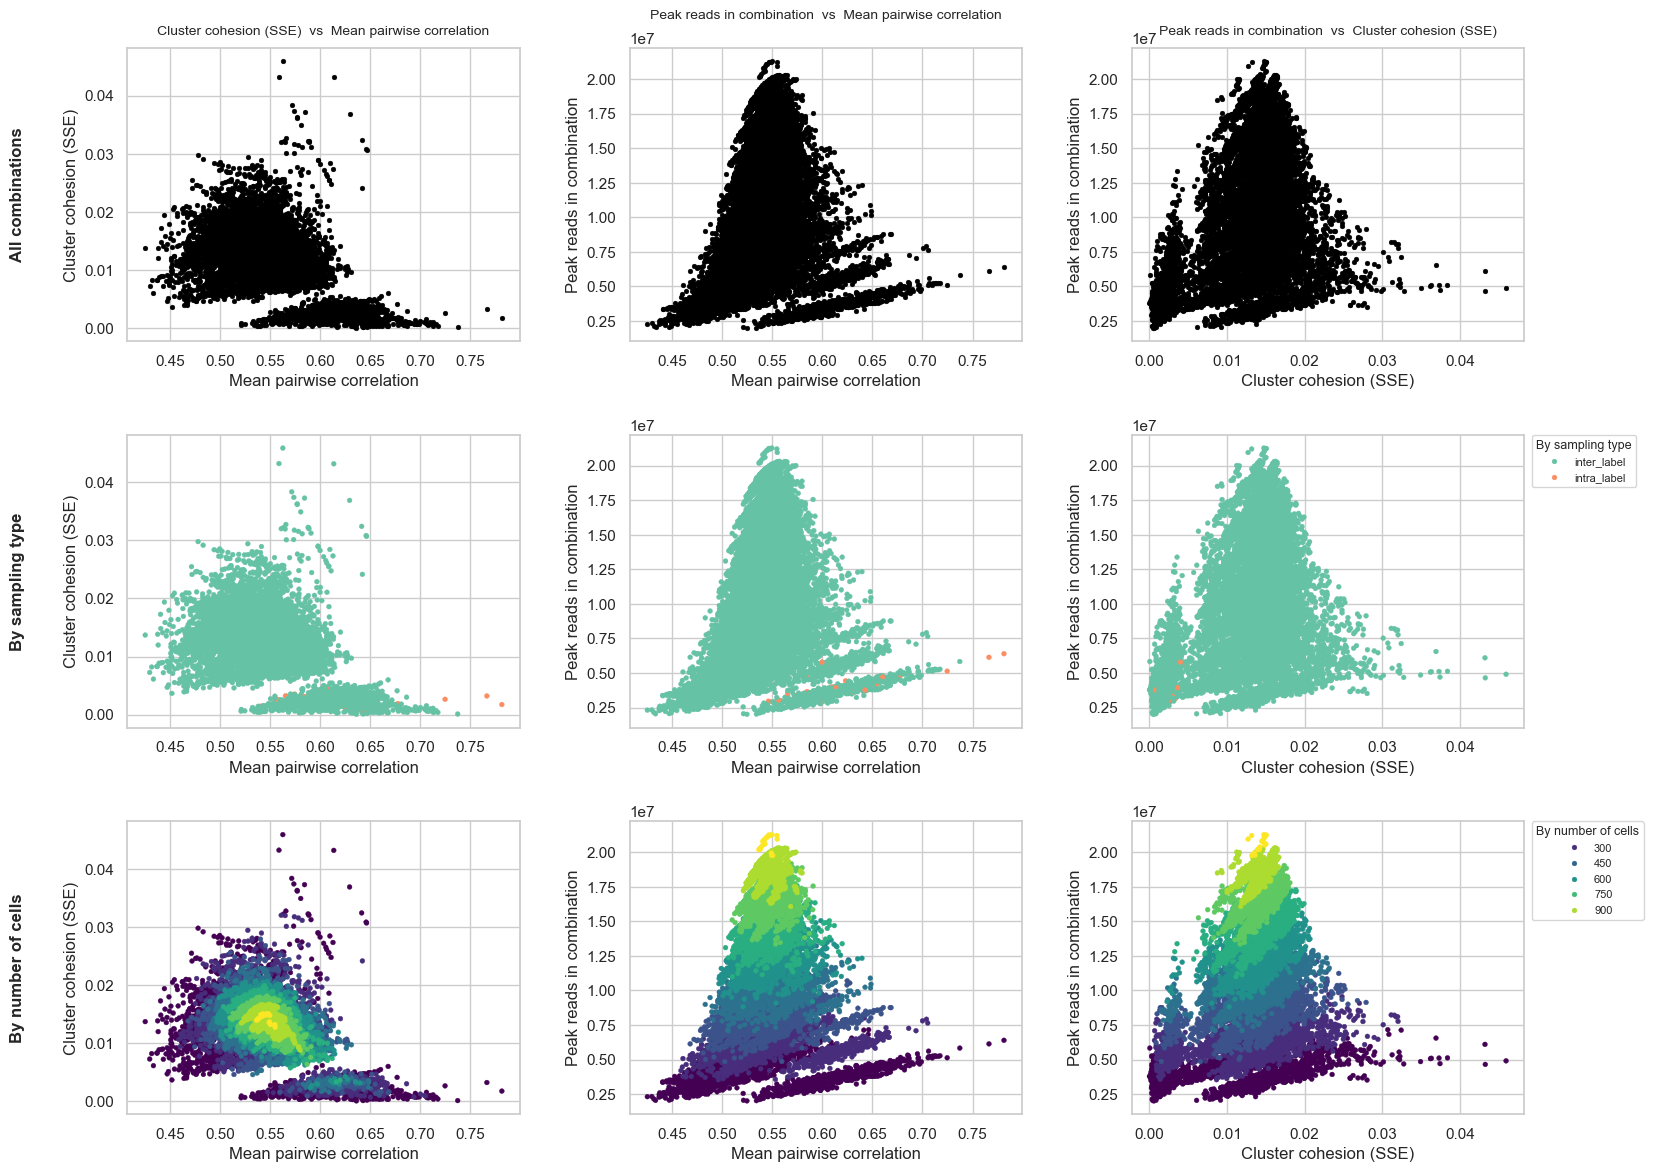

In [104]:
AXIS_LABELS = {
    "mean_pearson_corr": "Mean pairwise correlation",
    "sse_pearson_corr": "Cluster cohesion (SSE)",
    "total_peakreads": "Peak reads in combination",
}

pairs = [("mean_pearson_corr", "sse_pearson_corr"),
         ("mean_pearson_corr", "total_peakreads"),
         ("sse_pearson_corr", "total_peakreads")]

# row 1 is a single blue; rows 2 and 3 use palettes that avoid blue so the rows stay distinct
rows = [(None,              "All combinations",   None),
        ("sampling_type",   "By sampling type",   "Set2"),
        ("Number_of_Cells", "By number of cells", "viridis")]

sns.set(style='whitegrid')
fig, axes = plt.subplots(3, 3, figsize=(19, 13), squeeze=False)
fig.subplots_adjust(wspace=0.28, hspace=0.32, right=0.86, top=0.93)

for r, (hue, row_title, pal) in enumerate(rows):
    for c, (x, y) in enumerate(pairs):
        ax = axes[r][c]
        if hue is None:
            sns.scatterplot(data=combo_df, x=x, y=y, ax=ax, s=12,
                            color="black", edgecolor=None)
        else:
            sns.scatterplot(data=combo_df, x=x, y=y, ax=ax, hue=hue, s=12,
                            palette=pal, edgecolor=None)

        ax.set_xlabel(AXIS_LABELS[x]); ax.set_ylabel(AXIS_LABELS[y])

        if r == 0:   # column titles on the top row only
            ax.set_title(f"{AXIS_LABELS[y]}  vs  {AXIS_LABELS[x]}", fontsize=10, pad=10)

        if ax.get_legend() is not None:   # one legend per row, right of the last column
            if c == 2:
                ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,
                          title=row_title, fontsize=8, title_fontsize=9)
            else:
                ax.get_legend().remove()

    axes[r][0].annotate(row_title, xy=(-0.28, 0.5), xycoords='axes fraction',
                        ha='center', va='center', rotation=90,
                        fontsize=12, fontweight='bold')

plt.show()

### 3.5 Visualize results relative to one population (e.g. HEPG2)

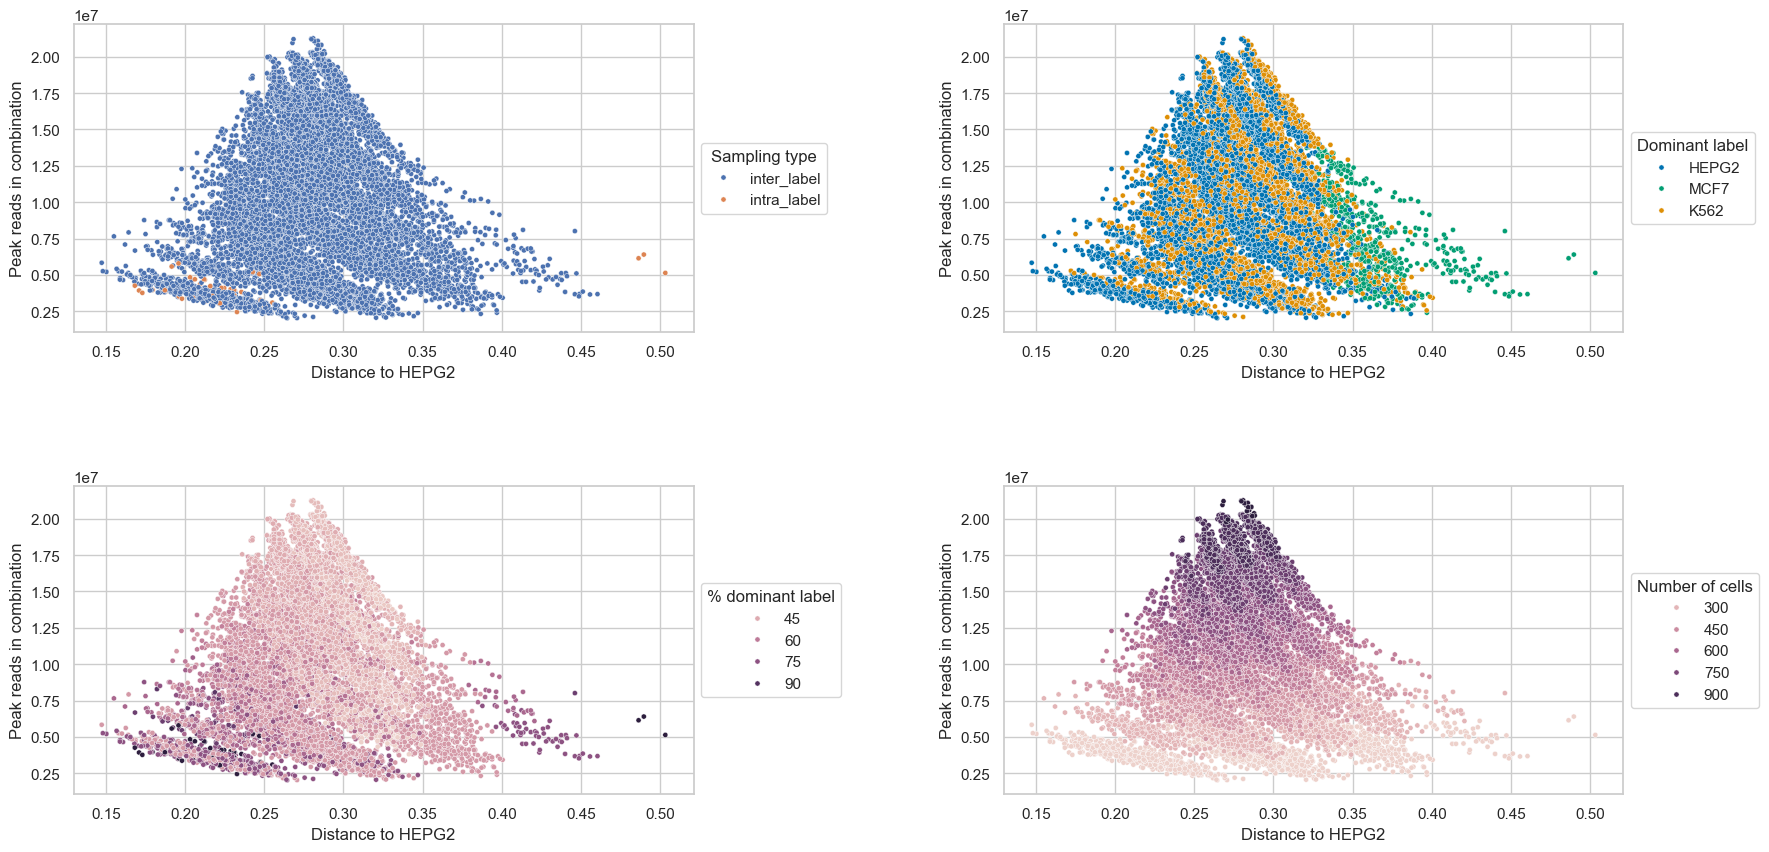

In [107]:
REF_LABEL = all_labels[0] #e.g. HEPG2

sns.set(style='whitegrid')
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 2, figure=fig, wspace=0.5, hspace=0.5)

tmp = combo_df_long[combo_df_long["dist_to_*"] == REF_LABEL]

panels = [("sampling_type", "Sampling type", None),
          ("dominant_label", "Dominant label", custom_palette),
          ("dominant_label_perc", "% dominant label", None),
          ("Number_of_Cells", "Number of cells", None)]

for k, (hue, title, pal) in enumerate(panels):
    ax = fig.add_subplot(gs[k])
    sns.scatterplot(data=tmp, x="label_dist", y="total_peakreads",
                    ax=ax, hue=hue, palette=pal, s=14)
    ax.set_xlabel(f"Distance to {REF_LABEL}")
    ax.set_ylabel("Peak reads in combination")
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title=title)

plt.show()

### 3.6 Filter to remove combinations you do not want
Two filters, matching `select-populations`:

* single-label populations sitting further than `MAX_INTRA_DIST` from their reference label — an
  extreme-distance point should be extreme because it mixes labels, not because one label
  correlates oddly with itself
* anything above `MAX_SSE`, i.e. populations whose member clusters disagree with each other

In [108]:
# filters, matching the select-populations defaults
MAX_SSE        = 0.06   # drop poorly cohesive combinations
MAX_INTRA_DIST = 0.5    # drop single-label combinations that sit far from their reference label

mask = (((combo_df_long["sampling_type"].str.startswith("intra_label")) &
         (combo_df_long["label_dist"] > MAX_INTRA_DIST)) |
        (combo_df_long["sse_pearson_corr"] > MAX_SSE))

print(f"removed: {mask.sum()} rows")
print(f"kept:    {(~mask).sum()} rows")
combo_df_long = combo_df_long[~mask].copy()

removed: 45 rows
kept:    46008 rows


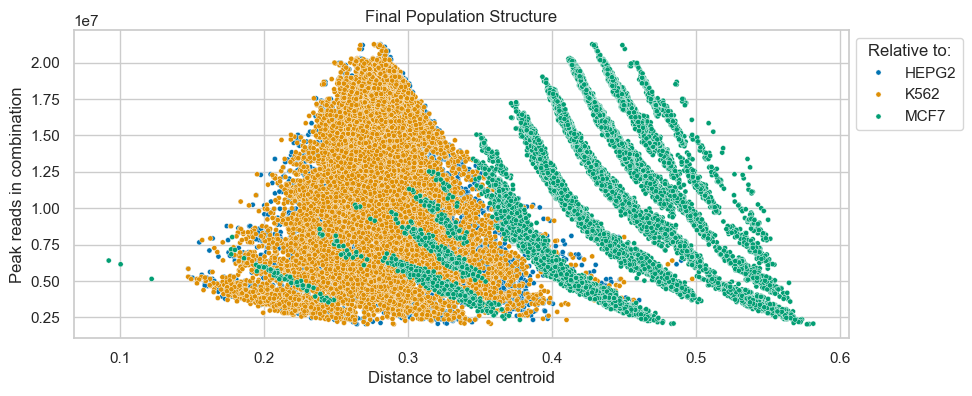

In [109]:
sns.set(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 4))

sns.scatterplot(data=combo_df_long, x="label_dist", y="total_peakreads",
                hue="dist_to_*", palette=custom_palette, ax=ax, s=14)
ax.set_xlabel("Distance to label centroid")
ax.set_ylabel("Peak reads in combination")
ax.set_title("Final Population Structure")

ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Relative to:")
plt.show()

### 3.8 Sanity check: what do the edge cases look like. 

Lets pull four populations from eacho corner of this space. 
1) Bottom left  - similar population with low read depth.
2) Bottom right - distant populations with low read depth.
3) Top left     - similar populations densely sampled.
4) Top right    - distant populations densely sampled. 

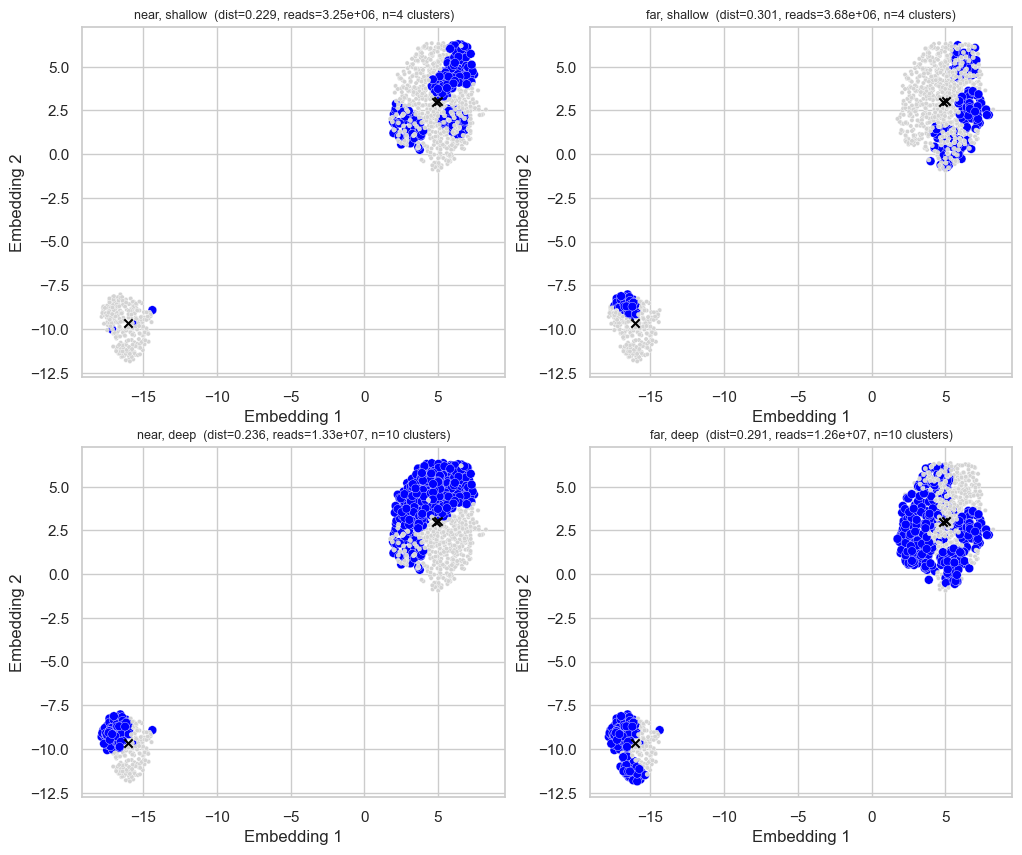

In [110]:
def _highlight(selected_combo, ax, title):
    embedding_df["local_color"] = 0
    embedding_df.loc[embedding_df["Cluster"].isin(selected_combo), "local_color"] = 1
    sns.scatterplot(x="embedding1", y="embedding2", hue='local_color',
                    data=embedding_df, legend=False, palette={0: "lightgrey", 1: "blue"},
                    size='local_color', sizes=(10, 40), size_order=[1, 0], ax=ax)
    ax.scatter(x="Kcenter_x", y="Kcenter_y",
               data=medoid_stats[medoid_stats.Cluster.isin(all_labels)],
               marker='x', color='black')
    ax.set_xlabel("Embedding 1"); ax.set_ylabel("Embedding 2")
    ax.set_title(title, fontsize=9)
    return ax


sub = combo_df_long[combo_df_long["dist_to_*"] == REF_LABEL]
d_lo, d_hi = sub["label_dist"].quantile([0.1, 0.55])
r_lo, r_hi = sub["total_peakreads"].quantile([0.1, 0.55])

corners = [("near, shallow", sub["label_dist"] <= d_lo, sub["total_peakreads"] <= r_lo),
           ("far, shallow",  sub["label_dist"] >= d_hi, sub["total_peakreads"] <= r_lo),
           ("near, deep",    sub["label_dist"] <= d_lo, sub["total_peakreads"] >= r_hi),
           ("far, deep",     sub["label_dist"] >= d_hi, sub["total_peakreads"] >= r_hi)]

sns.set(style='whitegrid')
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 2, figure=fig, wspace=0.2, hspace=0.2)

for k, (name, c_dist, c_depth) in enumerate(corners):
    ax = fig.add_subplot(gs[k])
    hits = sub.loc[c_dist & c_depth]
    if len(hits) == 0:
        ax.set_title(f"{name}: no combination in this corner", fontsize=9)
        continue
    row = hits.iloc[0]
    _highlight(row["group_medoids"], ax,
               f"{name}  (dist={row['label_dist']:.3f}, "
               f"reads={row['total_peakreads']:.2e}, n={len(row['group_medoids'])} clusters)")

plt.show()

# 4. Select populations <a class="anchor" id="four"></a>

Say you have two metrics you are interested in: cell similarity and read depth. We want to choose
on both together.

In [111]:
N_PER_GROUP = 5        # combinations to select per reference label, per depth bin

### 4.1 Bin both axes by quantile
Both axes are binned the same way, by quantile, so each bin holds a comparable number of candidates
regardless of how the values are distributed. Selection then takes the best candidate per distance
bin, which spreads the choices along the axis rather than clustering them wherever the data is
dense.

`N_DIST_BINS` sets the resolution along the similarity axis. `DEPTH_QUANTILES` sets the target
depths — the manuscript used 5e7, 1e8, 1.5e8 and 2e8 peak reads, taken from quantiles of that
dataset; deriving them here keeps this usable at any depth, since the tutorial subset is orders of
magnitude smaller and hardcoded values would select nothing.

In [112]:
N_DIST_BINS = 20                              # bins along the distance (similarity) axis
DEPTH_QUANTILES = [0.25, 0.50, 0.75, 0.95]    # target depths

# distance axis: quantile bins, numbered 1..N with increasing distance
combo_df_long["bin"] = pd.qcut(combo_df_long["label_dist"], q=N_DIST_BINS,
                               labels=False, duplicates="drop") + 1

# depth axis: quantile targets, with a half-window so a bin only draws candidates near it
read_depth_bins = [float(combo_df_long["total_peakreads"].quantile(q)) for q in DEPTH_QUANTILES]
depth_tolerance = float(np.diff(read_depth_bins).min() / 2)

print(f"distance: {combo_df_long['bin'].nunique()} bins across "
      f"{combo_df_long['label_dist'].min():.3f} - {combo_df_long['label_dist'].max():.3f}")
print("\ndepth targets:")
for q, b in zip(DEPTH_QUANTILES, read_depth_bins):
    print(f"  q{q:<5} -> {b:.3e}")
print(f"\ndepth_tolerance = +/- {depth_tolerance:.3e}")

distance: 20 bins across 0.092 - 0.581

depth targets:
  q0.25  -> 7.015e+06
  q0.5   -> 1.107e+07
  q0.75  -> 1.504e+07
  q0.95  -> 1.855e+07

depth_tolerance = +/- 1.754e+06


### 4.3 Select N per depth bin, spread along distance
For each depth bin, walk the distance bins and take the candidate closest to the target depth,
repeating until `N_PER_GROUP` are chosen. Candidates outside the tolerance window are skipped, so
a bin with nothing at the right depth contributes nothing rather than contributing a bad point.

In [113]:
def SelectPoints(df, desired_groups, yline, threshold, seed=42):
    rng = np.random.default_rng(seed)

    def _check_y(idx_to_flip):
        return df.loc[idx_to_flip, :].query(
            f"{yline - threshold} < total_peakreads < {yline + threshold}").index.to_list()

    df["selected"] = False
    dg = 0

    while dg != desired_groups:
        # per distance bin, the unselected candidate closest to the target depth
        idx_to_flip = df.loc[~df["selected"]].groupby("bin")["dif"].idxmin().to_numpy()
        idx_to_flip = _check_y(idx_to_flip)

        if len(idx_to_flip) == 0:
            print(f"  only {dg}/{desired_groups} available at depth {yline:.2e}")
            break

        if (len(idx_to_flip) + dg) < desired_groups:
            df.loc[idx_to_flip, "selected"] = True
            dg += len(idx_to_flip)
        else:
            remaining = desired_groups - dg
            chosen = rng.choice(idx_to_flip, size=remaining, replace=False)
            df.loc[chosen, "selected"] = True
            dg += len(chosen)

    return df[df["selected"]]


combo_df_long["selected"] = False
combo_df_long["read_group"] = "none"

for ref_label in all_labels:
    for yline in read_depth_bins:
        sub = combo_df_long[combo_df_long["dist_to_*"] == ref_label].copy()
        sub['dif'] = np.abs(sub["total_peakreads"] - yline)
        picked_df = SelectPoints(sub, desired_groups=N_PER_GROUP,
                                 yline=yline, threshold=depth_tolerance)
        combo_df_long.loc[picked_df.index, ["selected", "read_group"]] = [True, f"{yline:.2e}"]

print(f"\nselected {int(combo_df_long['selected'].sum())} of {len(combo_df_long)} rows")
display(combo_df_long[combo_df_long.selected].groupby(["dist_to_*", "read_group"]).size())


selected 60 of 46008 rows


dist_to_*  read_group
HEPG2      1.11e+07      5
           1.50e+07      5
           1.85e+07      5
           7.02e+06      5
K562       1.11e+07      5
           1.50e+07      5
           1.85e+07      5
           7.02e+06      5
MCF7       1.11e+07      5
           1.50e+07      5
           1.85e+07      5
           7.02e+06      5
dtype: int64

### 4.4 Visualize Which populations get picked. 
Candidates coloured by distance bin, selections marked in black, target depths as dashed lines.
Selections should sit on the dashed lines and spread across the x axis. Gaps mean no candidate
existed at that combination of distance and depth — worth knowing before footprinting, since it
is a hole in the design rather than a plotting artefact.

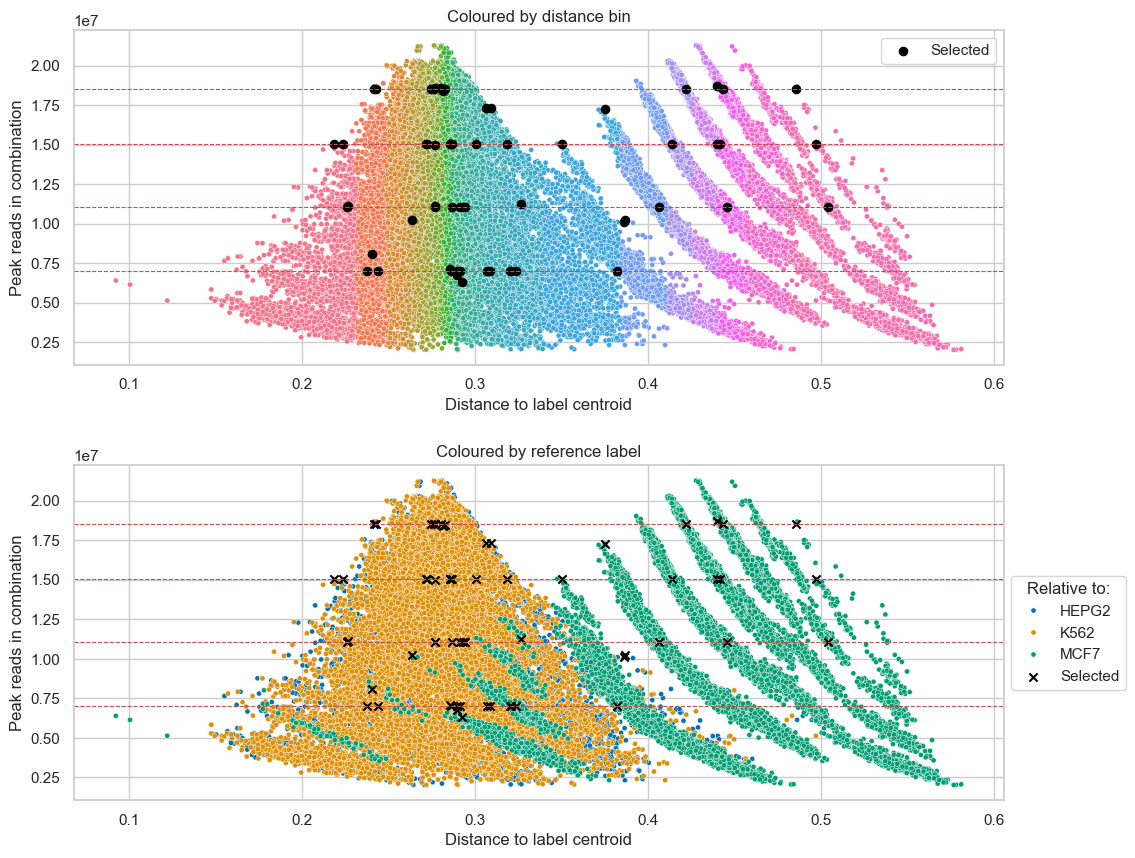

In [114]:
sns.set(style='whitegrid')
fig = plt.figure(figsize=(12, 10))
gs = GridSpec(2, 1, figure=fig, hspace=0.3)

bin_palette = sns.color_palette("husl", n_colors=combo_df_long.bin.nunique())

ax = fig.add_subplot(gs[0])
sns.scatterplot(data=combo_df_long, x="label_dist", y="total_peakreads",
                ax=ax, hue="bin", palette=bin_palette, s=14, legend=False)
ax.scatter(data=combo_df_long[combo_df_long.selected], x="label_dist", y="total_peakreads",
           s=35, marker="o", color='black', label='Selected')
for b in read_depth_bins:
    ax.axhline(y=b, color='r', linestyle='dashed', linewidth=0.8)
ax.set_xlabel("Distance to label centroid"); ax.set_ylabel("Peak reads in combination")
ax.set_title("Coloured by distance bin")
ax.legend(loc='upper right')

ax = fig.add_subplot(gs[1])
sns.scatterplot(data=combo_df_long, x="label_dist", y="total_peakreads",
                ax=ax, hue="dist_to_*", palette=custom_palette, s=14)
ax.scatter(data=combo_df_long[combo_df_long.selected], x="label_dist", y="total_peakreads",
           s=35, marker="x", color='black', label='Selected')
for b in read_depth_bins:
    ax.axhline(y=b, color='r', linestyle='dashed', linewidth=0.8)
ax.set_xlabel("Distance to label centroid"); ax.set_ylabel("Peak reads in combination")
ax.set_title("Coloured by reference label")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Relative to:")

plt.show()

### 4.5 Save the selections
Each selected population gets a stable `ComboID`. Duplicates — the same clusters selected against
more than one reference label — are reported rather than dropped, since whether that is a problem
depends on what you are doing with them.

In [115]:
tofootprint = combo_df_long[combo_df_long.selected].copy()
tofootprint = tofootprint.sort_values(["read_group", "dist_to_*"])
tofootprint["ComboID"] = tofootprint.groupby(
    tofootprint["group_medoids"].apply(lambda x: ",".join(sorted(x)))).ngroup()

dups = tofootprint[tofootprint.duplicated(subset=["ComboID"], keep=False)]
if len(dups):
    print(f"{tofootprint['ComboID'].nunique()} distinct populations across "
          f"{len(tofootprint)} rows; {len(dups)} rows share a population with another row")

out_csv = OUTDIR / "selected_combos.csv"
tofootprint.to_csv(out_csv, index=False)
print(f"wrote {out_csv}")
display(tofootprint.head())

46 distinct populations across 60 rows; 24 rows share a population with another row
wrote /Users/amandaeveritt/projects/scBAMpler/example_output/selected/selected_combos.csv


,group_medoids,total_peakreads,mean_pearson_corr,sse_pearson_corr,dominant_label,dominant_label_perc,closest_label,groups_sampled,sampling_type,Number_of_Cells,dist_to_*,label_dist,bin,selected,read_group,ComboID
4866,"[m13, m15, m17, m18, m19, m20, m21, m8]",10222468,0.566140,0.024196,MCF7,62.500000,MCF7,all,inter_label,400,HEPG2,0.386745,15,True,1.11e+07,42
6115,"[m11, m12, m14, m15, m17, m2, m5, m7, m8, m9]",11107184,0.603243,0.008460,K562,50.000000,K562,all,inter_label,500,HEPG2,0.226569,1,True,1.11e+07,31
7872,"[m1, m12, m13, m15, m16, m17, m18, m19, m3, m8]",11066915,0.542935,0.014971,K562,40.000000,K562,all,inter_label,500,HEPG2,0.291136,9,True,1.11e+07,20
8501,"[m10, m15, m16, m17, m18, m2, m21, m4, m6, m7,...",11055473,0.520425,0.013466,HEPG2,41.666667,HEPG2,all,inter_label,600,HEPG2,0.292945,10,True,1.11e+07,28
8655,"[m1, m10, m11, m12, m13, m15, m16, m2, m20, m2...",11094804,0.539151,0.011005,K562,50.000000,K562,all,inter_label,600,HEPG2,0.276882,7,True,1.11e+07,5


# 5. Write barcode files <a class="anchor" id="five"></a>

One file per (population, label), listing the cell barcodes belonging to that population's
clusters. The format is what `sinto filterbarcodes` expects for `--cells`: two space-separated
columns and no header.

Splitting by label is deliberate. A mixed population draws cells from several experiments, so
the reads have to come out of several BAMs — one `filterbarcodes` call per label against that
label's BAM, then merge.

In [116]:
bc_dir = OUTDIR / "barcodes"
bc_dir.mkdir(parents=True, exist_ok=True)

# barcodes in the H5 carry a "<Sample>#" prefix that is not present in the BAM's CB tag
embedding_df["CB2"] = embedding_df["CB"].astype(str).str.replace(r'^.*?#', '', regex=True)

written = []
for combo_id, sub_df in tofootprint.groupby("ComboID"):
    medoids = sub_df["group_medoids"].values[0]
    cb_df = embedding_df[embedding_df.Cluster.isin(medoids)]

    for lab, lab_df in cb_df.groupby(LABEL_COL):
        f = bc_dir / f"combo_{combo_id}.{lab}.barcodes.csv"
        lab_df[["CB2", LABEL_COL]].to_csv(f, index=False, header=False, sep=" ")
        written.append((combo_id, lab, len(lab_df), f.name))

summary = pd.DataFrame(written, columns=["ComboID", LABEL_COL, "n_cells", "file"])
print(f"wrote {len(summary)} files for {summary.ComboID.nunique()} populations into {bc_dir}")
display(summary.head(10))

wrote 135 files for 46 populations into /Users/amandaeveritt/projects/scBAMpler/example_output/selected/barcodes


,ComboID,CellLine,n_cells,file
0,0,HEPG2,400,combo_0.HEPG2.barcodes.csv
1,0,K562,400,combo_0.K562.barcodes.csv
2,0,MCF7,100,combo_0.MCF7.barcodes.csv
3,1,HEPG2,200,combo_1.HEPG2.barcodes.csv
4,1,K562,300,combo_1.K562.barcodes.csv
5,1,MCF7,200,combo_1.MCF7.barcodes.csv
6,2,HEPG2,250,combo_2.HEPG2.barcodes.csv
7,2,K562,300,combo_2.K562.barcodes.csv
8,2,MCF7,50,combo_2.MCF7.barcodes.csv
9,3,HEPG2,350,combo_3.HEPG2.barcodes.csv


### Extracting the BAMs
For each population, filter every contributing label's BAM to that population's barcodes, then
merge. Run outside the notebook:

```bash
COMBO=0
OUT=example_output/selected

for F in $OUT/barcodes/combo_${COMBO}.*.barcodes.csv; do
    LAB=$(basename "$F" .barcodes.csv); LAB=${LAB#combo_${COMBO}.}
    sinto filterbarcodes -b test_data/${LAB}_subset.bam -c "$F" -p 8 --outdir "$OUT"
done

samtools merge -o $OUT/combo_${COMBO}.bam $OUT/*_subset.bam
samtools index $OUT/combo_${COMBO}.bam
```

`sinto` names its output after the label in column 2, so the intermediate files land as
`<label>.bam` and are merged into a single population BAM.